## **Univariable EDA**

### Importing labraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer

### Loading data set

In [33]:
df=sns.load_dataset('titanic')

### Have a look on five random rows of the data

In [34]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
538,0,3,male,NaN,0,0,14.5000,S,Third,man,True,NaN,Southampton,no,True
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
517,0,3,male,NaN,0,0,24.1500,Q,Third,man,True,NaN,Queenstown,no,True
599,1,1,male,49.0,1,0,56.9292,C,First,man,True,A,Cherbourg,yes,False
499,0,3,male,24.0,0,0,7.7958,S,Third,man,True,NaN,Southampton,no,True


### Applying statics functions

In [35]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Columns of the data 

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### Missing values

In [37]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [38]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

## **Categorical columns**

### Sex column

In [39]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [40]:
df['sex'].isnull().sum()

0

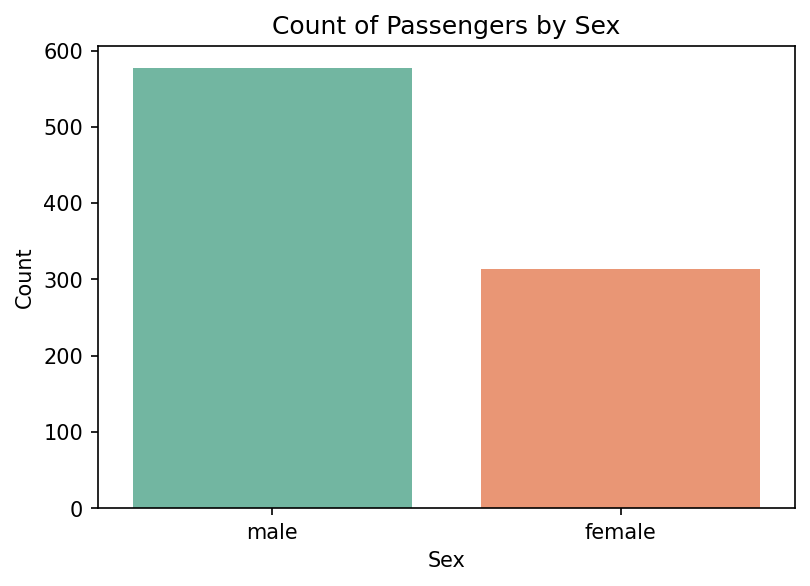

In [41]:
plt.figure(figsize=(6,4),dpi=150)
sns.countplot(data=df,x='sex',palette='Set2')
plt.title('Count of Passengers by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

### Embarked Column

In [42]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

### Filling missing values

In [43]:
impute=SimpleImputer(strategy='most_frequent')
df['embarked']=impute.fit_transform(df[['embarked']]).ravel()

In [44]:
df['embarked'].isnull().sum()

0

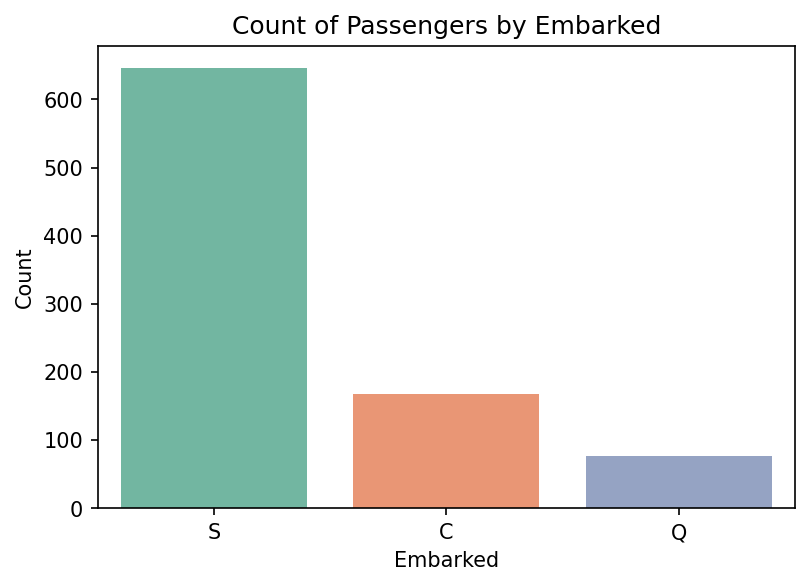

In [45]:
plt.figure(figsize=(6,4),dpi=150)
sns.countplot(data=df,x='embarked',palette='Set2')
plt.title('Count of Passengers by Embarked')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()

### Class column

In [46]:
df['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [47]:
df['class'].isnull().sum()

0

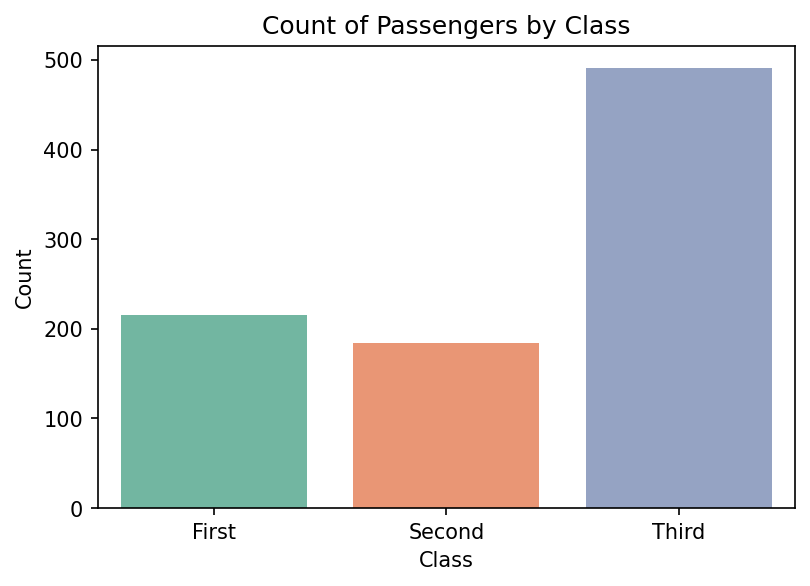

In [48]:
plt.figure(figsize=(6,4),dpi=150)
sns.countplot(data=df,x='class',palette='Set2')
plt.title('Count of Passengers by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

### Adult male column

In [49]:
df['adult_male'].value_counts()

adult_male
True     537
False    354
Name: count, dtype: int64

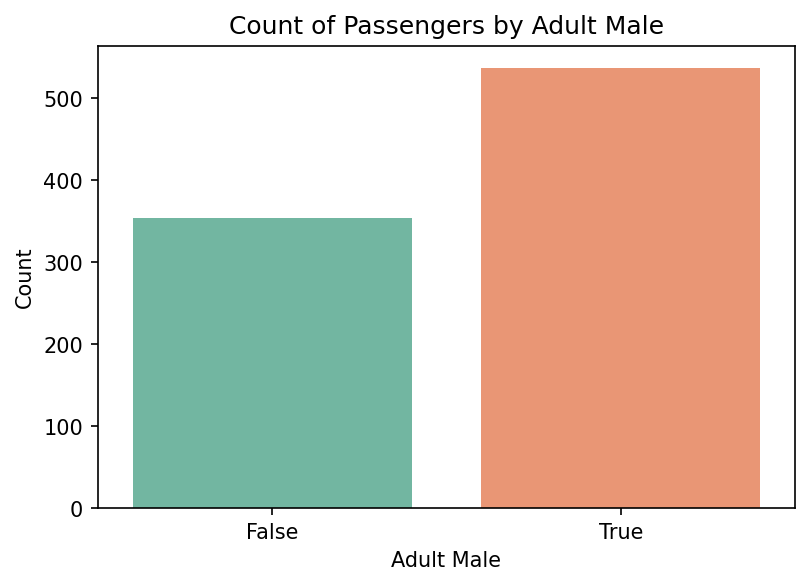

In [50]:
plt.figure(figsize=(6,4),dpi=150)
sns.countplot(data=df,x='adult_male',palette='Set2')
plt.title('Count of Passengers by Adult Male')
plt.xlabel('Adult Male')
plt.ylabel('Count')
plt.show()


### Alone column

In [51]:
df['alone'].value_counts()

alone
True     537
False    354
Name: count, dtype: int64

In [52]:
df['alone'].isnull().sum()

0

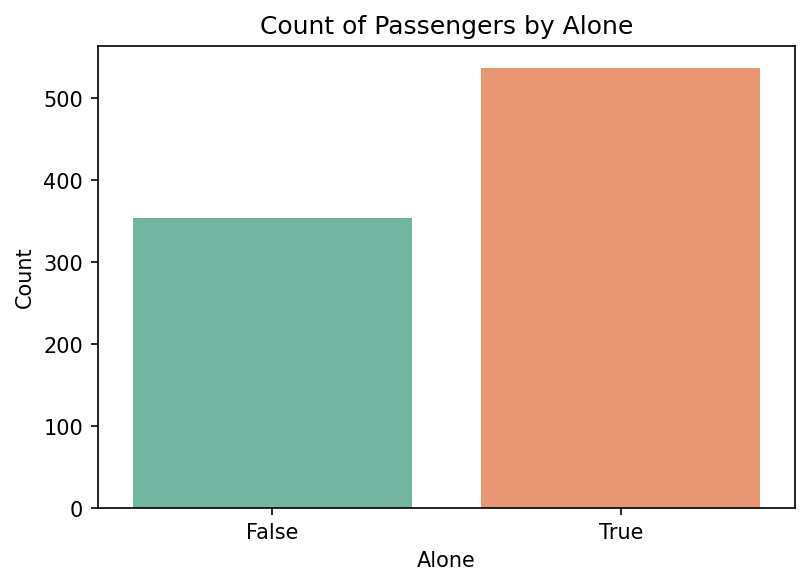

In [53]:
plt.figure(figsize=(6,4),dpi=150)
sns.countplot(data=df,x='alone',palette='Set2')
plt.title('Count of Passengers by Alone')
plt.xlabel('Alone')
plt.ylabel('Count')
plt.show()

## **Numerical columns**

### Age column

In [54]:
df['age'].isnull().sum()

177

In [63]:
df['age'].describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: age, dtype: float64

### Filling missing values

In [55]:
imputer=SimpleImputer(strategy='mean')
df['age']=imputer.fit_transform(df[['age']]).ravel()

In [56]:
df['age'].isnull().sum()

0

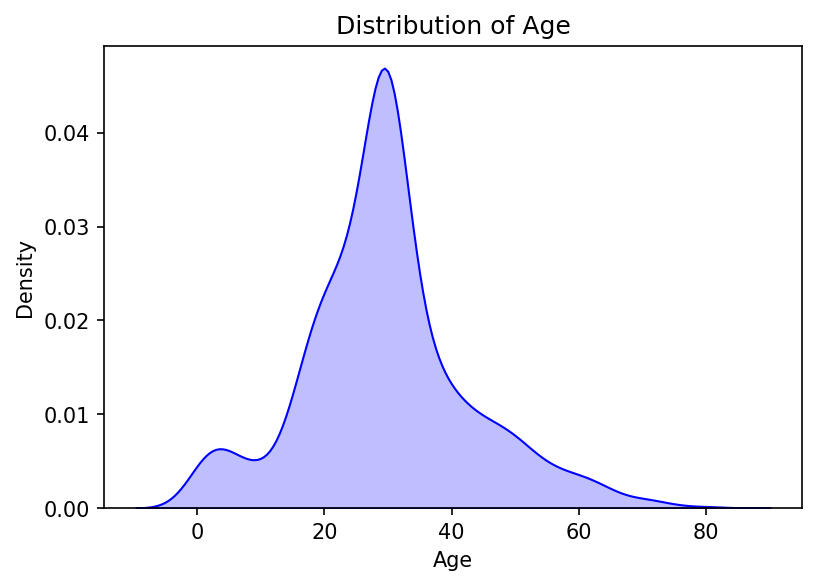

In [59]:
plt.figure(figsize=(6,4),dpi=150)
sns.kdeplot(data=df,x='age',shade=True,color='blue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

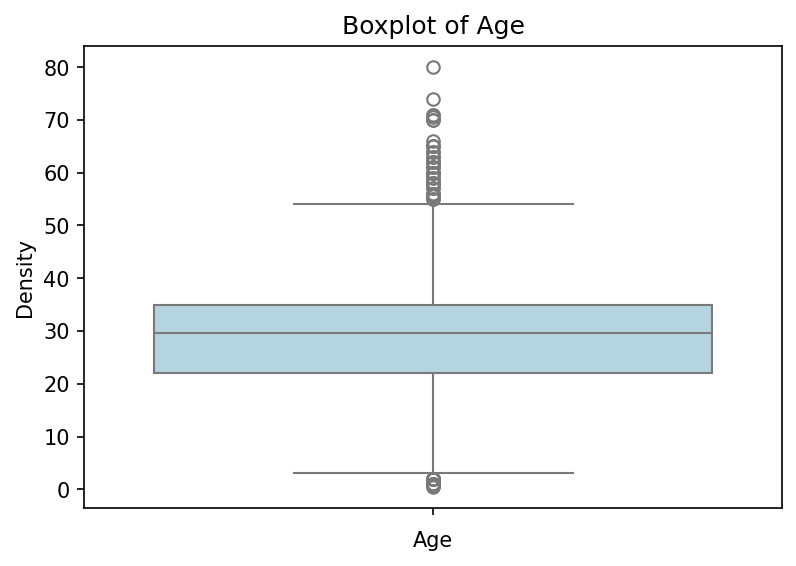

In [61]:
plt.figure(figsize=(6,4),dpi=150)
sns.boxplot(data=df,y='age',color='lightblue')
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

### Fare column

In [64]:
df['fare'].isnull().sum()

0

In [65]:
df['fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

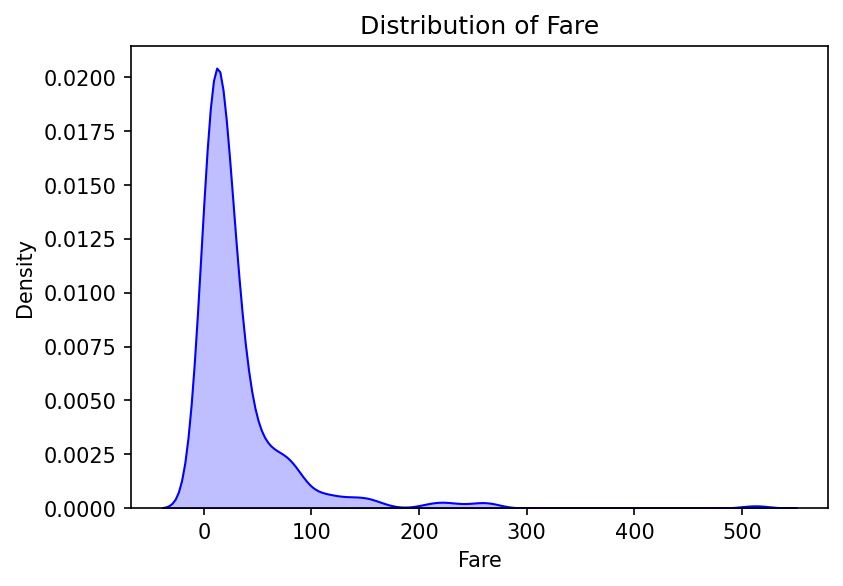

In [66]:
plt.figure(figsize=(6,4),dpi=150)
sns.kdeplot(data=df,x='fare',shade=True,color='blue')
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

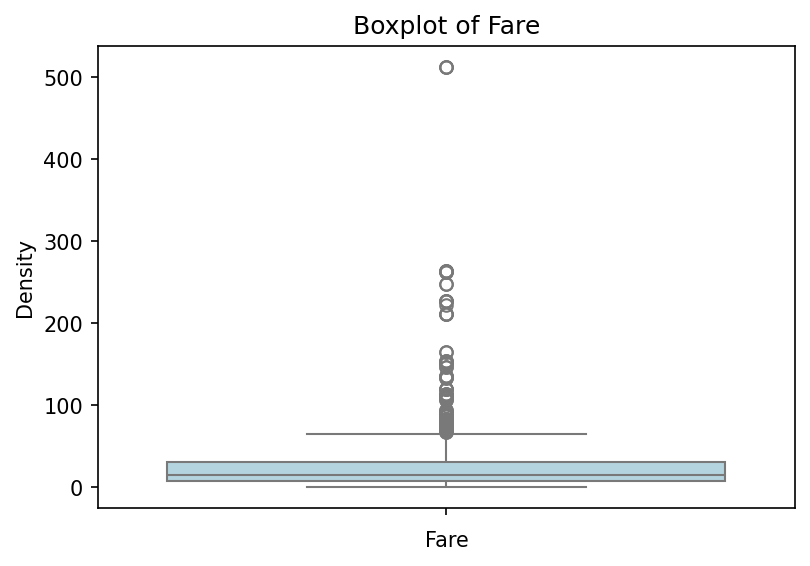

In [73]:
plt.figure(figsize=(6,4),dpi=150)
sns.boxplot(data=df,y='fare',color='lightblue')
plt.title("Boxplot of Fare")
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

## Survived column

In [69]:
df['survived'].isnull().sum()

0

In [70]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

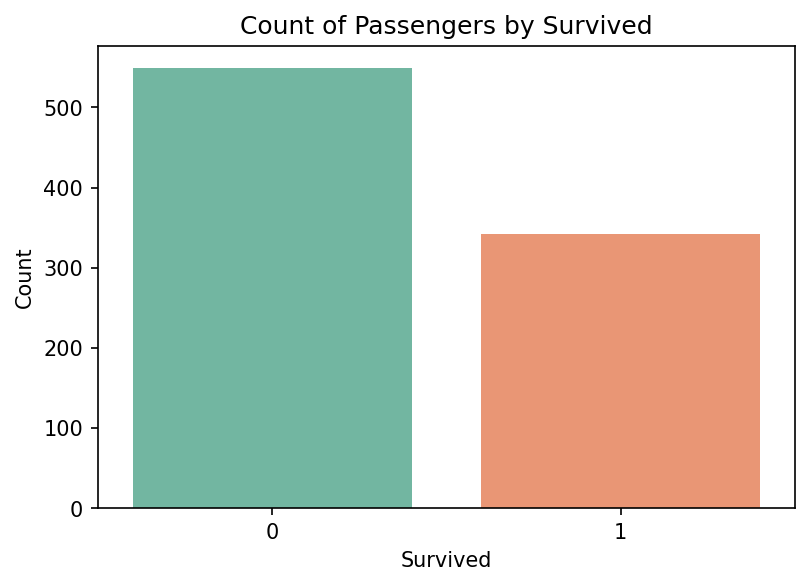

In [83]:
plt.figure(figsize=(6,4),dpi=150)
sns.countplot(data=df,x='survived',palette='Set2')
plt.title('Count of Passengers by Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

In [81]:
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [82]:
df['pclass'].isnull().sum()

0

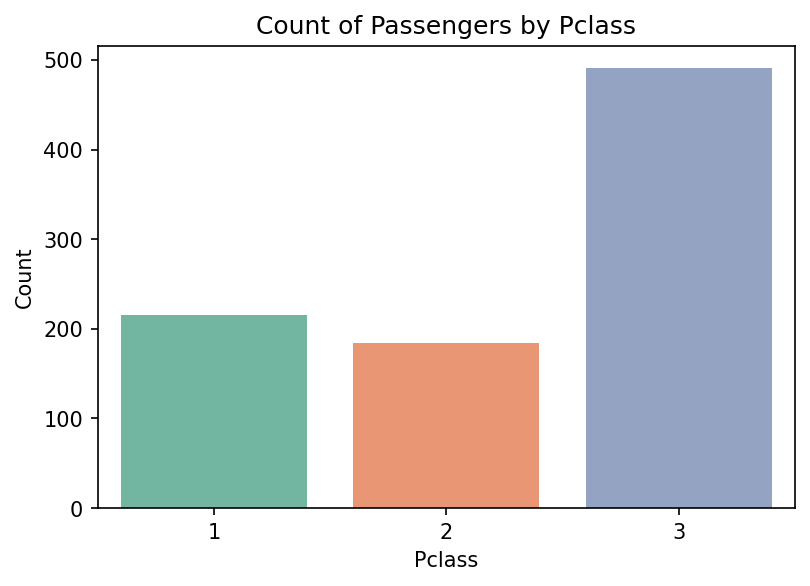

In [84]:
plt.figure(figsize=(6,4),dpi=150)
sns.countplot(data=df,x='pclass',palette='Set2')
plt.title('Count of Passengers by Pclass')
plt.ylabel('Count')
plt.xlabel('Pclass')
plt.show()